In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/CBEM_pytorch
    # !pip install -r requirements.txt
    # Uninstall CPU jax/jaxlib if present
    # !pip uninstall -y jax jaxlib

    # # Install GPU-enabled JAX (choose the right cuda extra for your Colab)
    # # Try cuda12 first (common in Colab recently):
    # !pip install -U "jax[cuda12]"


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from utils._raised_cosine_basis import makeRaisedCosBasis
from utils.load_matlab import load_mat_v73, flatten_cell
import utils
from utils import *
import torch.nn.functional as F
import h5py
import math
import torch.nn as nn
from utils.CBEM import CBEM

In [3]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.10.0+cu128
CUDA available: False


## Create simulated data

In [ ]:
# load stimulus and spike times from the matlab file
filename = "Data/example.mat"
with h5py.File(filename, "r") as f:
    stimulus  = np.array(list(f["X"]))[0]
    CBEM_True = np.array(list(f["CBEM_true"]))
cbem_data = load_mat_v73("Data/example.mat", "CBEM_true")
dt = 1e-4
# dt      = float(cbem_data["dt"])
# E_l     = float(cbem_data["E_l"])
# initV   = float(cbem_data["initV"])
# g_l     = float(cbem_data["g_l"])
# log_g_l = float(cbem_data["log_g_l"])

# E_s     = np.array(cbem_data["E_s"]).squeeze()
# g_s_bar = np.array(cbem_data["g_s_bar"]).squeeze()

stimBasisVectors = np.array(cbem_data["stimBasisVectors"]).T
stimNumBasisVectors = int(np.squeeze(cbem_data["stimNumBasisVectors"]))
spkHistBasisVectors = np.array(cbem_data["spkHistBasisVectors"])


In [ ]:
ke_m = [ 3.3466, -0.0550, -4.5200,  1.1226,  2.5813,  0.9879, -1.4976, -0.9441,
         1.0484, -0.2074, 34.1294]

ki_m = [-13.0572, -16.9142,  19.4609,   9.3509,  -4.4428,  -8.8496,  -2.9373,
          3.7958,   3.3145,   3.3381,  47.5604]
ke_m = torch.tensor(ke_m, device=device)
ki_m = torch.tensor(ki_m, device=device)

In [8]:
nLinearRFs = 10 #;     %number of stimulus basis functions
numShortSHFilts = 5#; %each is 0.4ms long - used for refractory period
nSHfilters = 7+numShortSHFilts#;%7+

nInh = 1#;
nExc = 1#

RFstart = 2e-3 #;%0?
RFend   = 150e-3#;%150e-3 or 180e-3;
b = 0.02
t, B_orth, B_raw = makeRaisedCosBasis(nLinearRFs, dt, [RFstart, RFend], b, zflag=0)


# Observation Model

In [9]:
stimulus_t = torch.as_tensor(stimulus, dtype=torch.float32, device=device)
B_orth_t   = torch.as_tensor(B_orth,   dtype=torch.float32, device=device)

X_full = convolveStimulusWithBasis_torch(stimulus_t, B_orth_t, add_ones=True)  # [T, D]

CBEM_true = CBEM(binsize_s=dt).to(device)
CBEM_true.eval()

# make sure B_cond exists (D = X_full.shape[1])
CBEM_true._maybe_init_B_cond_from_D(
    D=X_full.shape[1],
    device=X_full.device,
    dtype=X_full.dtype
)

# Build GT parameters in the SAME basis used by X_full (orth basis)
with torch.no_grad():
    Bstim = torch.as_tensor(stimBasisVectors, device=device, dtype=CBEM_true.B_cond.dtype)  # [L,P]
    Borth = B_orth_t                                                                            # [L,P]
    P = Borth.shape[1]

    ke_stim, be = ke_m[:P], ke_m[P]
    ki_stim, bi = ki_m[:P], ki_m[P]

    # Bstim ≈ Borth @ R, so k_orth = R @ k_stim where R = Borth.T @ Bstim
    R = Borth.T @ Bstim
    ke_orth = R @ ke_stim
    ki_orth = R @ ki_stim

    B_cond = torch.zeros(X_full.shape[1], 2, device=device, dtype=CBEM_true.B_cond.dtype)
    B_cond[:P, 0] = ke_orth
    B_cond[:P, 1] = ki_orth
    B_cond[P, 0] = be
    B_cond[P, 1] = bi

    CBEM_true.B_cond.copy_(B_cond)

Y_init = torch.zeros(500, 1, device=X_full.device)
sps_t = CBEM_true.simulateSpikeTrains(X_full, Y_init, N=1, seed=0)

Fr_t, extras = CBEM_true(X_full)
Fr = Fr_t.detach().cpu().numpy()
sps = sps_t.detach().cpu().numpy()



In [10]:
# # P basis coeffs + bias from MATLAB params
# ke_m = torch.tensor(k_s_list[0], device=device, dtype=CBEM_true.B_cond.dtype)
# ki_m = torch.tensor(k_s_list[1], device=device, dtype=CBEM_true.B_cond.dtype)

P = B_orth_t.shape[1]
ke_stim, be = ke_m[:P], ke_m[P]
ki_stim, bi = ki_m[:P], ki_m[P]

Bstim = torch.as_tensor(stimBasisVectors, device=device, dtype=CBEM_true.B_cond.dtype)  # [L,P]
Borth = B_orth_t  # [L,P]

# Convert stim-basis coeffs -> orth-basis coeffs
R = Borth.T @ Bstim                   # Bstim ≈ Borth @ R
ke_orth = torch.linalg.solve(R, ke_stim)
ki_orth = torch.linalg.solve(R, ki_stim)

with torch.no_grad():
    B_cond = torch.zeros(X_full.shape[1], 2, device=device, dtype=CBEM_true.B_cond.dtype)
    B_cond[:P, 0] = ke_orth
    B_cond[:P, 1] = ki_orth
    B_cond[P, 0] = be
    B_cond[P, 1] = bi
    CBEM_true.B_cond.copy_(B_cond)
    

Y_init = torch.zeros(500, 1, device=X_full.device)   
sps_t = CBEM_true.simulateSpikeTrains(X_full, Y_init, N=1, seed=0)  # [T,20]
    

Fr_t, extras = CBEM_true(X_full)
Fr = Fr_t.detach().cpu().numpy()
sps = sps_t.detach().cpu().numpy()   


In [11]:
spkTimes_bins = [np.where(sps[:, n] > 0)[0] for n in range(sps.shape[1])]
spkTimes_ms_by_trial = [idx * dt * 1e3 for idx in spkTimes_bins]
# plt.eventplot(spkTimes_ms_by_trial, color='k', alpha=0.6)

In [12]:
# import numpy as np
# import matplotlib.pyplot as plt

# def plot_raster_eventplot(sps, dt_s, ax=None):
#     sps = np.asarray(sps)
#     T, N = sps.shape
#     ax = ax or plt.gca()

#     events = [np.flatnonzero(sps[:, n]) * dt_s * 1e3 for n in range(N)]  # list of arrays in ms
#     ax.eventplot(events, colors='k', lineoffsets=np.arange(N), linelengths=0.8)
#     ax.set_xlabel("Time (ms)")
#     ax.set_ylabel("Trial")
#     ax.set_ylim(-0.5, N - 0.5)
#     return ax

# fig, ax = plt.subplots(figsize=(10, 4))
# plot_raster_eventplot(sps, dt_s=dt, ax=ax)
# plt.show()

/tmp/ipykernel_49940/3446615195.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


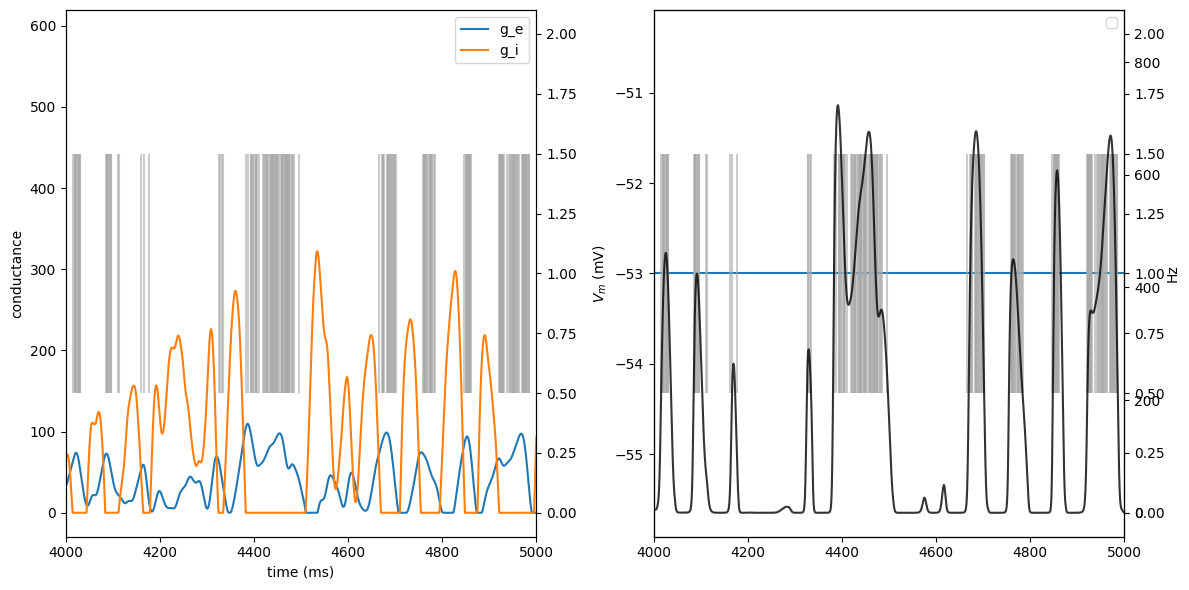

In [13]:
gs = extras['gs'].detach().cpu().numpy()
Vm = extras['V'].detach().cpu().numpy()
# X_cond = extras['X_cond'].detach().cpu().numpy()

## General shape is okay but we are off but a scale factor and not including the leak conductance!!
pltLength_bins = 70000
t_ms = np.arange(pltLength_bins)*dt*1e3 
fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].plot(t_ms, gs[0:pltLength_bins,:], label=["g_e", "g_i"])
spikes = axes[0].twinx()
spikes.eventplot(spkTimes_ms_by_trial, color='darkgray', alpha=0.6)
axes[0].set_xlabel('time (ms)')
axes[0].set_ylabel('conductance')

# axes[1].plot(t_ms, Vm[:pltLength_bins])
spikes = axes[1].twinx()
spikes.eventplot(spkTimes_ms_by_trial, color='darkgray', alpha=0.6)
axes[1].axhline(-53)
axes[1].set_ylabel(r'$V_m \text{ (mV)}$')
rate_ax = axes[1].twinx()
rate_ax.plot(t_ms, Fr[0:pltLength_bins], label='Spike Rate', c='k', alpha =0.8)
rate_ax.set_ylabel("Hz")
for ax in axes:
    ax.set_xlim(4000,5000)
    ax.legend()
fig.tight_layout()
plt.show()

GT recon error (orth vs stim reconstruction): 6.719948260069941e-07


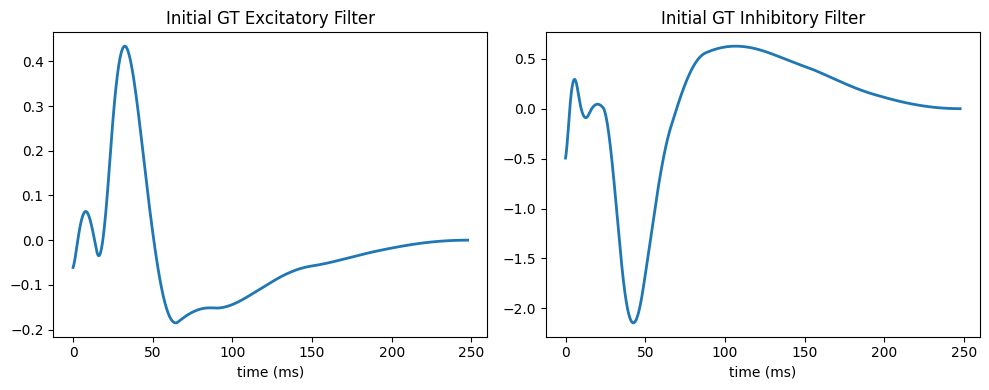

In [15]:
# Plot initial GT filters reconstructed consistently
stimBasisVectors_t = torch.as_tensor(stimBasisVectors, device=device, dtype=CBEM_true.B_cond.dtype)  # [L,P]
Borth = torch.as_tensor(B_orth, device=device, dtype=CBEM_true.B_cond.dtype)                          # [L,P]

W_true = CBEM_true.B_cond.detach()  # [D,2], currently in orth basis
P = stimBasisVectors_t.shape[1]
W_true_orth = W_true[:P, :]         # [P,2]

# Convert orth -> stim coefficients for plotting in MATLAB/stim basis
R = Borth.T @ stimBasisVectors_t    # Bstim ≈ Borth @ R
W_true_stim = torch.linalg.solve(R, W_true_orth)

# Time-domain GT filters in stim basis
f_e_from_model = stimBasisVectors_t @ W_true_stim[:, 0]   # [L]
f_i_from_model = stimBasisVectors_t @ W_true_stim[:, 1]   # [L]

# Also keep orth-basis recon for sanity
f_true_orth = Borth @ W_true_orth
f_true_stim = torch.stack([f_e_from_model, f_i_from_model], dim=1)
print('GT recon error (orth vs stim reconstruction):', float((f_true_orth - f_true_stim).norm() / f_true_orth.norm()))

# Plot initial GT filters
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
t_ms = np.arange(f_e_from_model.shape[0]) * dt * 1e3

axes[0].plot(t_ms, f_e_from_model.detach().cpu().numpy(), lw=2)
axes[0].set_title('Initial GT Excitatory Filter')
axes[0].set_xlabel('time (ms)')

axes[1].plot(t_ms, f_i_from_model.detach().cpu().numpy(), lw=2)
axes[1].set_title('Initial GT Inhibitory Filter')
axes[1].set_xlabel('time (ms)')

plt.tight_layout()
plt.show()



## Loss and fit!

In [ ]:
def poisson_nll_truncated_from_spike_bins(rate: torch.Tensor,
                                         spkTimes_bins: torch.Tensor,
                                         binsize_s: float,
                                         eps= 1e-8) -> torch.Tensor:
    """
    Truncated-Poisson / Bernoulli-per-bin likelihood.
     Based on Citi et. al 2014: product of T bernoulli trials. Works if max 1 spk/bin
    logp
    \log_p(y_{1:T}\mid \textbf{x}_{1:T}, \Theta ) = 
    \sum_{t=1}^T y_t \log(1- \exp(-\lambda_t \Delta ))-(1- y_t)\lambda_t\Delta
    
    Args:
    rate: [T] firing rate in spikes/second (Hz)
    binsize_s: seconds per bin (self.binsize_s)
    spkTimes_bins: indices (0..T-1) of bins that contain a spike (or >=1 spike)

    Log-likelihood per bin:
      ll_t = -lam_t                                  if y_t = 0
      ll_t = log(1 - exp(-lam_t))                    if y_t = 1
    where lam_t = rate_t * binsize_s  (expected count in bin)

    Returns:
      nll: scalar negative log-likelihood (sum over bins)
    """
    lam = rate * binsize_s                      # [T]
    ll = -lam                                   # default no-spike

    spk_idx = torch.as_tensor(spkTimes_bins, device=rate.device, dtype=torch.long)
    spk_idx = spk_idx[(spk_idx >= 0) & (spk_idx < lam.shape[0])]
    if spk_idx.numel() > 0:
        spk_idx = torch.unique(spk_idx)

        # log(1 - exp(-lam)) = log(-expm1(-lam)) stable for small lam
        p_spike = (-torch.expm1(-lam[spk_idx])).clamp_min(eps)  # in (0,1]
        ll_spike = torch.log(p_spike)

        ll = ll.clone()
        ll[spk_idx] = ll_spike

    return -ll.sum()

def cbem_penalized_nll(model,
                       stimulus: torch.Tensor,
                       spkTimes_bins: torch.Tensor,
                       window=None,
                       conductance_penalty=(1.0, 0.2)) -> torch.Tensor:
    """
    Penalized NLL:
      nll = truncated_poisson_nll(rate)
      + sum_c pen[c] * ||B_cond[:-1, c]||^2

    Excludes last row of B_cond (baseline term), matching JAX.
    """
    rate, _ = model(stimulus, window=window)  # calls forward
    nll = poisson_nll_truncated_from_spike_bins(rate, spkTimes_bins, model.binsize_s)

    B = model.B_cond
    if B is None:
        raise RuntimeError("model.B_cond is None. Run model once to initialize B_cond.")

    W = B[:-1, :]  # exclude baseline row
    pen = torch.as_tensor(conductance_penalty, device=W.device, dtype=W.dtype)  # [2]

    # generic form (works even if you later change #conductances)
    if pen.numel() != W.shape[1]:
        raise ValueError(f"conductance_penalty has {pen.numel()} elements but B_cond has {W.shape[1]} columns.")

    nll = nll + (pen * (W**2).sum(dim=0)).sum()
    return nll

In [ ]:
import torch
import torch.nn.functional as F

# ----------------------------
# 1) Helper: build spike-bin indices from a 0/1 vector (or counts) y[t]
# ----------------------------
def spike_bins_from_y(y: torch.Tensor):
    """
    y: [T] or [T,1] with 0/1 (or >=1) spikes per bin
    returns: 1D long tensor of indices where y>0
    """
    if y.ndim == 2:
        y = y[:, 0]
    return torch.where(y > 0)[0].to(torch.long)

# ----------------------------
# 2) A simple training loop
# ----------------------------
def train_cbem(
    model,
    X_cond: torch.Tensor,              # [T,D] design matrix (your X_full)
    spkTimes_bins: torch.Tensor,       # 1D long indices of spike bins
    *,
    lr=1e-2,
    weight_decay=0.0,                  # usually keep 0 here; we already add explicit penalty
    conductance_penalty=(1.0, 0.2),
    n_steps=2000,
    print_every=100,
    clip_grad_norm=1.0,
    window_size=None,                  # e.g. 20000 for minibatch-in-time
    seed=0,
):
    torch.manual_seed(seed)
    device = X_cond.device

    # Ensure parameters exist (B_cond is lazy)
    with torch.no_grad():
        _ = model(X_cond[:10])  # initializes B_cond based on D

    # Optimizer only over parameters (B_cond)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Optional: simple time-minibatching by sampling a contiguous window each step
    T = X_cond.shape[0]
    loss_vals = []
    history_steps = []
    for step in range(1, n_steps + 1):
        model.train()
        opt.zero_grad(set_to_none=True)

        if window_size is None:
            window = None
            loss = cbem_penalized_nll(
                model=model,
                stimulus=X_cond,
                spkTimes_bins=spkTimes_bins,
                window=window,
                conductance_penalty=conductance_penalty,
            )
        else:
            # pick a random contiguous window [start, start+W)
            W = int(window_size)
            start = torch.randint(low=0, high=max(1, T - W), size=(1,), device=device).item()
            window = torch.arange(start, start + W, device=device, dtype=torch.long)

            # IMPORTANT: restrict spike indices to this window and convert to local indices
            spk_local = spkTimes_bins[(spkTimes_bins >= start) & (spkTimes_bins < start + W)] - start

            loss = cbem_penalized_nll(
                model=model,
                stimulus=X_cond,
                spkTimes_bins=spk_local,
                window=window,  # model slices X_cond[window]
                conductance_penalty=conductance_penalty,
            )

        loss.backward()

        if clip_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float(clip_grad_norm))

        opt.step()

        if (step % print_every) == 0 or step == 1:
            model.eval()
            with torch.no_grad():
                rate, aux = model(X_cond)
                lam = rate * model.binsize_s
                # crude sanity: mean predicted rate and mean spike prob
                mean_rate_hz = float(rate.mean())
                mean_p = float((-torch.expm1(-lam)).mean())
            loss_vals.append(loss)
            history_steps.append(step)
            print(f"step {step:5d} | loss {float(loss):.3f} | mean rate {mean_rate_hz:.3f} Hz | mean p {mean_p:.6f}")
    return model, (history_steps, loss_vals)

spk_idx = torch.as_tensor(spkTimes_bins[0], device=X_full.device, dtype=torch.long)

model = CBEM(binsize_s=dt).to(device)
trained,  (steps_hist, loss_hist)= train_cbem(
    model,
    X_cond=X_full,
    spkTimes_bins=spk_idx,
    lr=4e-2,
    conductance_penalty=(.01, 0.001),
    n_steps=5000,
    print_every=100,
    clip_grad_norm=1.0,
    window_size=None,   # set None to train full sequence each step
)

# After training, your learned basis weights are:
B_cond_learned = trained.B_cond.detach().cpu()   # [D,2]

In [ ]:
plt.figure()
steps_hist = np.array(steps_hist)
loss_hist = np.array([l.detach().cpu().numpy() for l in loss_hist])
plt.plot(steps_hist, loss_hist, marker='o')
# plt.vlines([1000, 3000, 5000,6000], ymin = 0, ymax=10000)
plt.xlabel("Iteration (step)")
plt.ylabel("Penalized NLL")
plt.title("Training loss vs iteration")
plt.tight_layout()
plt.show()

In [ ]:
B = B_cond_learned          # [D,2]
W_orth = B[:-1, :]          # [P,2] learned coeffs in orth basis (drop bias row)
bias = B[-1, :]             # [2]

Borth = torch.as_tensor(B_orth, device=W_orth.device, dtype=W_orth.dtype)          # [L,P]
Bstim = torch.as_tensor(stimBasisVectors, device=W_orth.device, dtype=W_orth.dtype) # [L,P]

# Change-of-basis matrix: Bstim ≈ Borth @ R
# R = Borth.T @ Bstim                                                              # [P,P]
R = torch.linalg.lstsq(Borth, Bstim).solution
# or: R = torch.linalg.solve(Borth.T @ Borth, Borth.T @ Bstim)

# Convert learned orth-coeffs -> MATLAB/stim-basis coeffs
W_stim = torch.linalg.solve(R, W_orth)                                           # [P,2]

# Time-domain filters reconstructed in each basis (must match up to numerical error)
f_learned_orth = Borth @ W_orth                                                  # [L,2]
f_learned_stim = Bstim @ W_stim                                                  # [L,2]

recon_err = float((f_learned_orth - f_learned_stim).norm() / f_learned_orth.norm())
print('recon error (should be tiny):', recon_err)

# Keep convenient vectors for plotting
f_e_learned = f_learned_stim[:, 0]
f_i_learned = f_learned_stim[:, 1]

t_ms = torch.arange(Borth.shape[0], device=W_orth.device) * (dt * 1e3)



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
t_ms_np = t_ms.detach().cpu().numpy()

# Compare in the SAME basis (MATLAB stim basis)

axes[0].plot(t_ms_np, f_e_from_model.detach().cpu().numpy(), label='True', lw=2)
axes[0].plot(t_ms_np, f_e_learned.detach().cpu().numpy(), '--', label='learned', lw=2)
axes[0].set_title('Excitatory filter')
axes[0].set_xlabel('time (ms)')
axes[0].legend(loc='best')

axes[1].plot(t_ms_np, f_i_from_model.detach().cpu().numpy(), label='True', lw=2)
axes[1].plot(t_ms_np, f_i_learned.detach().cpu().numpy(), '--', label='Learned', lw=2)
axes[1].set_title('Inhibitory filter')
axes[1].set_xlabel('time (ms)')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()



In [ ]:
trained.eval()
Fr_train, extras_trained = trained(X_full, window=None)
Fr_train = Fr_train.detach().cpu().numpy()

gs_train = extras_trained['gs'].detach().cpu().numpy()
Vm = extras_trained['V'].detach().cpu().numpy()

# Compare trained vs ground-truth conductances and firing rate
pltLength_bins = min(70000, gs_train.shape[0], gs.shape[0], Fr_train.shape[0], Fr.shape[0])
t_ms = np.arange(pltLength_bins) * dt * 1e3

fig = plt.figure(figsize=(10, 4.5))
Gs = fig.add_gridspec(nrows=2, ncols=2, width_ratios=[1, 2], height_ratios=[1, 1])

g_Exc = fig.add_subplot(Gs[0, 0])
g_Inh = fig.add_subplot(Gs[1, 0])
rate_ax = fig.add_subplot(Gs[:, 1])

cmap_bwr = plt.get_cmap('bwr')
# Excitation: blue tones; inhibition: red tones
exc_trained_c = cmap_bwr(0.22)
exc_true_c = cmap_bwr(0.10)
inh_trained_c = cmap_bwr(0.78)
inh_true_c = cmap_bwr(0.90)

g_Exc.plot(t_ms, gs[:pltLength_bins, 0], label='Ground truth', lw=1.8, alpha=0.70, color='k')
g_Exc.plot(t_ms, gs_train[:pltLength_bins, 0], label='Trained', lw=1.8, color=exc_trained_c)
g_Exc.set_title('Excitatory conductance')
g_Exc.set_ylabel('Conductance (nS)')

g_Inh.plot(t_ms, gs[:pltLength_bins, 1], label='Ground truth', lw=1.8, alpha=0.70, color='k')
g_Inh.plot(t_ms, gs_train[:pltLength_bins, 1], label='Trained', lw=1.8, color=inh_trained_c)
g_Inh.set_title('Inhibitory conductance')
g_Inh.set_xlabel('Time (ms)')
g_Inh.set_ylabel('Conductance (nS)')

rate_ax.plot(t_ms, Fr_train[:pltLength_bins], label='Trained', lw=1.8)
rate_ax.plot(t_ms, Fr[:pltLength_bins], label='Ground truth', lw=1.8, alpha=0.85, c='k')
rate_ax.set_title('Firing rate')
rate_ax.set_xlabel('Time (ms)')
rate_ax.set_ylabel('Rate (Hz)')

# Use one x-range for all panels
xlim_ms = (4000.0, 5000.0)
if t_ms.size > 0:
    lo = max(float(t_ms[0]), xlim_ms[0])
    hi = min(float(t_ms[-1]), xlim_ms[1])
    if hi <= lo:
        lo, hi = float(t_ms[0]), float(t_ms[-1])
    for ax in (g_Exc, g_Inh, rate_ax):
        ax.set_xlim(lo, hi)
        ax.legend(loc='best')
        # ax.grid(alpha=0.25, linestyle='--', linewidth=0.7)

fig.suptitle('Ground truth vs trained: conductances and firing rate', y=1.03)
fig.tight_layout()
plt.show()


## To do:

- Initial Conditions!